# Paper Replication: SDFMFCC-based Non-Invasive Blood Glucose Estimation

**Paper:** Photoplethysmography based non-invasive blood glucose estimation using systolic-diastolic framing MFCC features and machine learning regression  
**Journal:** BioImpacts, 2025 | **PMC:** [PMC12413980](https://pmc.ncbi.nlm.nih.gov/articles/PMC12413980/)  
**Applied to:** GlucoSense primary dataset — Nigerian T2DM cohort (primary data collection)

---

## What this notebook does

This notebook **strictly replicates** the SDFMFCC pipeline from the above paper, applied to our primary dataset collected from T2DM patients in Nigeria.

### Replication scope
- **Preprocessing:** Savitzky-Golay filter → systolic/diastolic peak detection → pulse segmentation
- **Features:** MFCC extracted from systolic and diastolic frames of each PPG pulse (SDFMFCC), aggregated across beats; PPG-only (no demographics)
- **Models:** SVR (RBF), Decision Tree, Random Forest, AdaBoost, Gradient Boosting — identical to paper
- **MFCC variants:** N_MFCC ∈ {13, 20} tested to identify optimal coefficient count (paper did not specify)

### Three evaluation schemes (key scientific contribution)
| Scheme | Strategy | Approximates |
|---|---|---|
| 1 | Random 80/20 train/test split | Paper's likely methodology |
| 2 | 5-fold stratified KFold | Randomised cross-validation |
| 3 | **GroupKFold (subject-independent)** | **Honest generalisation evaluation** |

The gap between Scheme 1 and Scheme 3 is the primary finding.

---
> **Note on expected results:** The paper reports 99.8% accuracy with RMSE = 26.01 mg/dL on 23 subjects.
> This almost certainly reflects subject-level data leakage (same subjects in train and test).
> Our subject-independent evaluation (Scheme 3) provides the honest generalisation estimate.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
import neurokit2 as nk
import librosa
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sklearn.decomposition import PCA
import joblib
import os
import json

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Signal Parameters ─────────────────────────────────────────────────────────
SAMPLING_RATE    = 50       # Hz
TRIM_SECONDS     = 5        # seconds to discard from each end
ANALYSIS_SECONDS = 60       # usable window
ANALYSIS_SAMPLES = SAMPLING_RATE * ANALYSIS_SECONDS  # 3000

# ── Savitzky-Golay Filter ─────────────────────────────────────────────────────
SG_WINDOW    = 11   # window length (odd, ~220ms at 50 Hz)
SG_POLYORDER = 3    # polynomial order

# ── MFCC ──────────────────────────────────────────────────────────────────────
N_MFCC_VALUES = [13, 20]    # test both; paper did not specify

# ── ML / CV ───────────────────────────────────────────────────────────────────
N_SPLITS   = 5
TEST_SIZE  = 0.20

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH    = 'data/real/glucosense_r_dataset_2026-09-04.csv'
RESULTS_DIR  = 'results'
FIGURES_DIR  = 'figures'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Sampling rate : {SAMPLING_RATE} Hz")
print(f"  Analysis window: {ANALYSIS_SECONDS}s ({ANALYSIS_SAMPLES} samples)")
print(f"  SG filter: window={SG_WINDOW}, polyorder={SG_POLYORDER}")
print(f"  MFCC variants: {N_MFCC_VALUES}")
print(f"  CV splits: {N_SPLITS}")


Configuration loaded.
  Sampling rate : 50 Hz
  Analysis window: 60s (3000 samples)
  SG filter: window=11, polyorder=3
  MFCC variants: [13, 20]
  CV splits: 5


## 1. Data Loading
Load the GlucoSense primary dataset and parse raw PPG samples.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print()

recordings = []
parse_errors = []

for idx, row in df_raw.iterrows():
    try:
        ppg_str = row['ppg_data']
        ppg_full = np.array([float(x) for x in ppg_str.split(';') if x.strip()])
        
        # Trim first/last TRIM_SECONDS
        trim_n = TRIM_SECONDS * SAMPLING_RATE
        ppg = ppg_full[trim_n : trim_n + ANALYSIS_SAMPLES]
        
        if len(ppg) < ANALYSIS_SAMPLES:
            parse_errors.append({
                'session_id': row['session_id'],
                'reason': f'Only {len(ppg)} samples after trim (expected {ANALYSIS_SAMPLES})'
            })
        
        recordings.append({
            'session_id'     : row['session_id'],
            'participant_id' : row['participant_id'],
            'bgl_mgdl'       : float(row['bgl_mgdl']),
            'ppg_raw'        : ppg_full,   # full 70s signal
            'ppg'            : ppg,        # trimmed 60s window
            'n_samples'      : len(ppg),
            'age'            : row.get('age', np.nan),
            'gender'         : row.get('gender', np.nan),
            'weight_kg'      : row.get('weight_kg', np.nan),
            'height_cm'      : row.get('height_cm', np.nan),
            'session_kind'   : row.get('session_kind', np.nan),
        })
    except Exception as e:
        parse_errors.append({'session_id': row['session_id'], 'reason': str(e)})

print(f"Total recordings loaded : {len(recordings)}")
print(f"Unique participants     : {len(set(r['participant_id'] for r in recordings))}")
print(f"Parse errors            : {len(parse_errors)}")
if parse_errors:
    for e in parse_errors[:5]:
        print(f"  {e}")

bgls = np.array([r['bgl_mgdl'] for r in recordings])
print(f"\nBGL stats — mean={bgls.mean():.1f}, std={bgls.std():.1f}, "
      f"min={bgls.min():.0f}, max={bgls.max():.0f} mg/dL")


Raw dataset shape: (73, 13)
Columns: ['session_id', 'created_at', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'medication', 'session_kind', 'bgl_mgdl', 'ppg_samples_count', 'ppg_data']

Total recordings loaded : 73
Unique participants     : 63
Parse errors            : 0

BGL stats — mean=151.5, std=54.8, min=73, max=394 mg/dL


## 2. Preprocessing (Paper's Pipeline)

### Step 1 — Savitzky-Golay Filter
The paper applies a Savitzky-Golay filter for denoising while preserving PPG morphology.  
Parameters: `window_length=11` (~220 ms at 50 Hz), `polyorder=3`.

Unlike a band-pass filter, SG filtering is a local polynomial smoothing method — it does not attenuate
physiologically meaningful morphological features (systolic peak, diastolic trough), which is why the
paper chose it for preserving the systolic/diastolic structure needed for SDFMFCC.


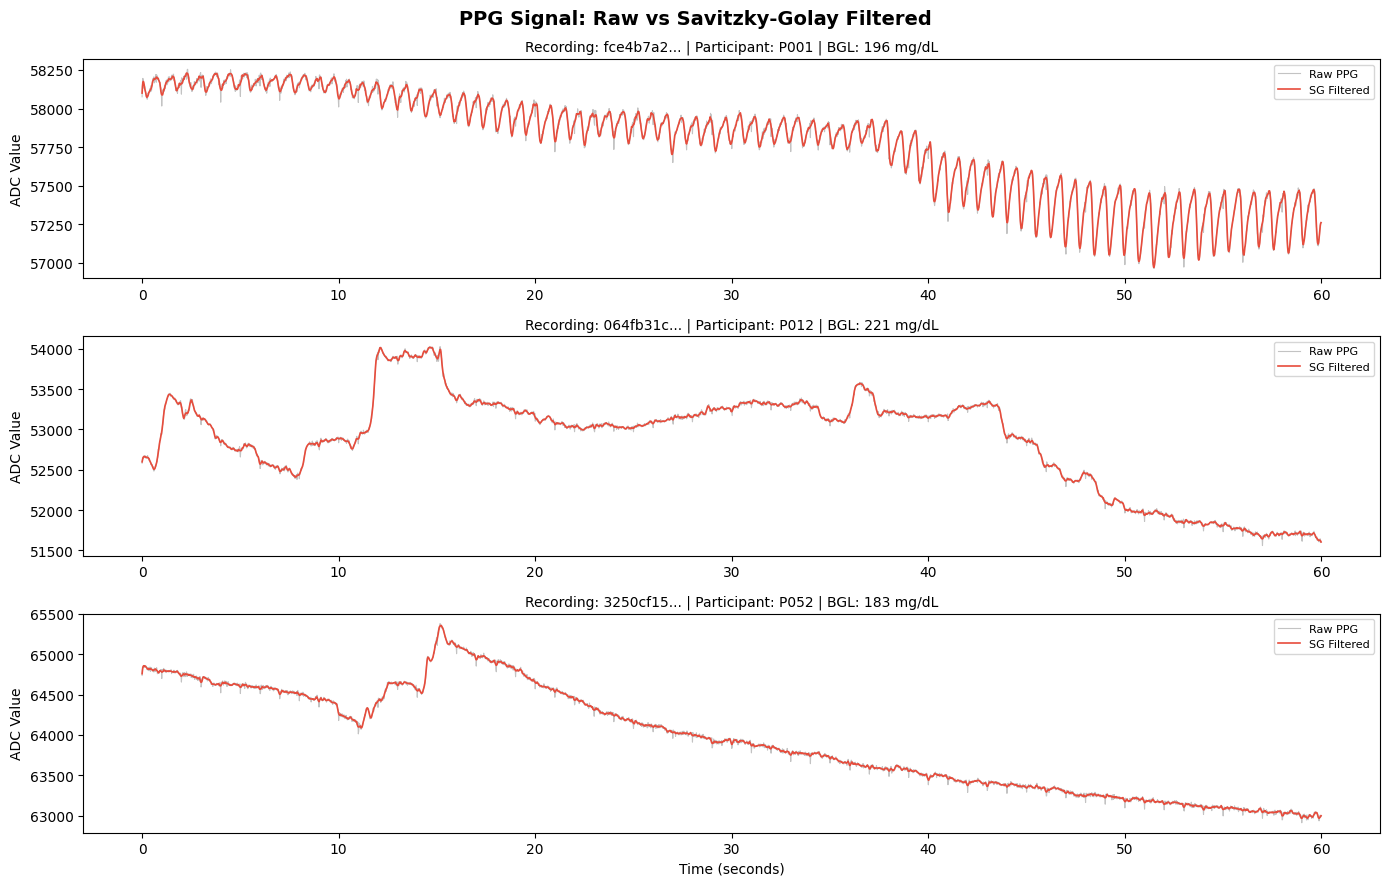

Savitzky-Golay filter applied to all recordings.


In [3]:
def apply_savgol(ppg, window=SG_WINDOW, polyorder=SG_POLYORDER):
    """Apply Savitzky-Golay smoothing filter."""
    return savgol_filter(ppg, window_length=window, polyorder=polyorder)

# Apply to all recordings
for rec in recordings:
    rec['ppg_sg'] = apply_savgol(rec['ppg'])

# ── Visualise: raw vs SG-filtered for 3 recordings ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('PPG Signal: Raw vs Savitzky-Golay Filtered', fontsize=14, fontweight='bold')

sample_indices = [0, len(recordings)//2, len(recordings)-1]
t = np.arange(ANALYSIS_SAMPLES) / SAMPLING_RATE

for ax, i in zip(axes, sample_indices):
    rec = recordings[i]
    ax.plot(t, rec['ppg'],    alpha=0.5, color='#888888', linewidth=0.8, label='Raw PPG')
    ax.plot(t, rec['ppg_sg'], color='#E74C3C', linewidth=1.2, label='SG Filtered')
    ax.set_title(f"Recording: {rec['session_id'][:8]}... | "
                 f"Participant: {rec['participant_id']} | BGL: {rec['bgl_mgdl']:.0f} mg/dL",
                 fontsize=10)
    ax.set_ylabel('ADC Value')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_sg_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Savitzky-Golay filter applied to all recordings.")


### Step 2 — Systolic Peak Detection & Pulse Segmentation

After SG filtering, local extrema are detected to identify:
- **Systolic peaks** (maximum of each pulse)
- **Pulse onsets/troughs** (minima between pulses)

Each pulse is then split into:
- **Systolic frame**: onset → systolic peak
- **Diastolic frame**: systolic peak → next onset


In [4]:
def detect_peaks_and_segment(ppg_sg, sr=SAMPLING_RATE):
    """
    Detect systolic peaks and segment each pulse into systolic + diastolic frames.
    Returns list of (systolic_frame, diastolic_frame) tuples.
    """
    try:
        # Use NeuroKit2 for robust PPG peak detection on SG-filtered signal
        signals, info = nk.ppg_process(ppg_sg, sampling_rate=sr)
        peaks = info['PPG_Peaks']
    except Exception as e:
        return [], [], str(e)

    if len(peaks) < 2:
        return [], [], "Too few peaks detected"

    # Compute troughs (local minima between consecutive peaks)
    troughs = []
    # Onset before first peak
    seg = ppg_sg[:peaks[0]]
    troughs.append(int(np.argmin(seg)) if len(seg) > 0 else 0)
    # Troughs between peaks
    for i in range(len(peaks) - 1):
        seg = ppg_sg[peaks[i]:peaks[i+1]]
        local_min = int(np.argmin(seg)) + peaks[i]
        troughs.append(local_min)
    # Onset after last peak
    seg = ppg_sg[peaks[-1]:]
    troughs.append(int(np.argmin(seg)) + peaks[-1] if len(seg) > 0 else len(ppg_sg) - 1)

    systolic_frames  = []
    diastolic_frames = []

    for i, peak in enumerate(peaks):
        onset = troughs[i]
        try:
            next_onset = troughs[i + 1]
        except IndexError:
            next_onset = len(ppg_sg) - 1

        # Systolic: onset → peak
        sf = ppg_sg[onset:peak + 1]
        # Diastolic: peak → next onset
        df_seg = ppg_sg[peak:next_onset + 1]

        if len(sf) >= 2 and len(df_seg) >= 2:
            systolic_frames.append(sf.astype(np.float32))
            diastolic_frames.append(df_seg.astype(np.float32))

    return systolic_frames, diastolic_frames, None


# Run segmentation on all recordings
seg_stats = []
failed_recordings = []

for rec in recordings:
    sf, df_seg, err = detect_peaks_and_segment(rec['ppg_sg'])
    rec['systolic_frames']  = sf
    rec['diastolic_frames'] = df_seg
    rec['seg_error']        = err
    rec['n_valid_pulses']   = len(sf)

    if err or len(sf) < 3:
        failed_recordings.append({
            'session_id': rec['session_id'],
            'participant_id': rec['participant_id'],
            'error': err,
            'n_pulses': len(sf)
        })

    seg_stats.append({
        'session_id'  : rec['session_id'],
        'bgl_mgdl'    : rec['bgl_mgdl'],
        'n_pulses'    : len(sf),
        'error'       : err
    })

seg_df = pd.DataFrame(seg_stats)
print(f"Segmentation complete.")
print(f"  Successful : {(seg_df['n_pulses'] >= 3).sum()} / {len(recordings)}")
print(f"  Failed / <3 pulses: {len(failed_recordings)}")
print(f"  Mean pulses per recording: {seg_df['n_pulses'].mean():.1f} "
      f"(min={seg_df['n_pulses'].min()}, max={seg_df['n_pulses'].max()})")
if failed_recordings:
    print("\nFailed recordings:")
    for f in failed_recordings:
        print(f"  {f['session_id'][:12]}... | {f['participant_id']} | pulses={f['n_pulses']} | {f['error']}")


Segmentation complete.
  Successful : 73 / 73
  Failed / <3 pulses: 0
  Mean pulses per recording: 73.8 (min=5, max=105)


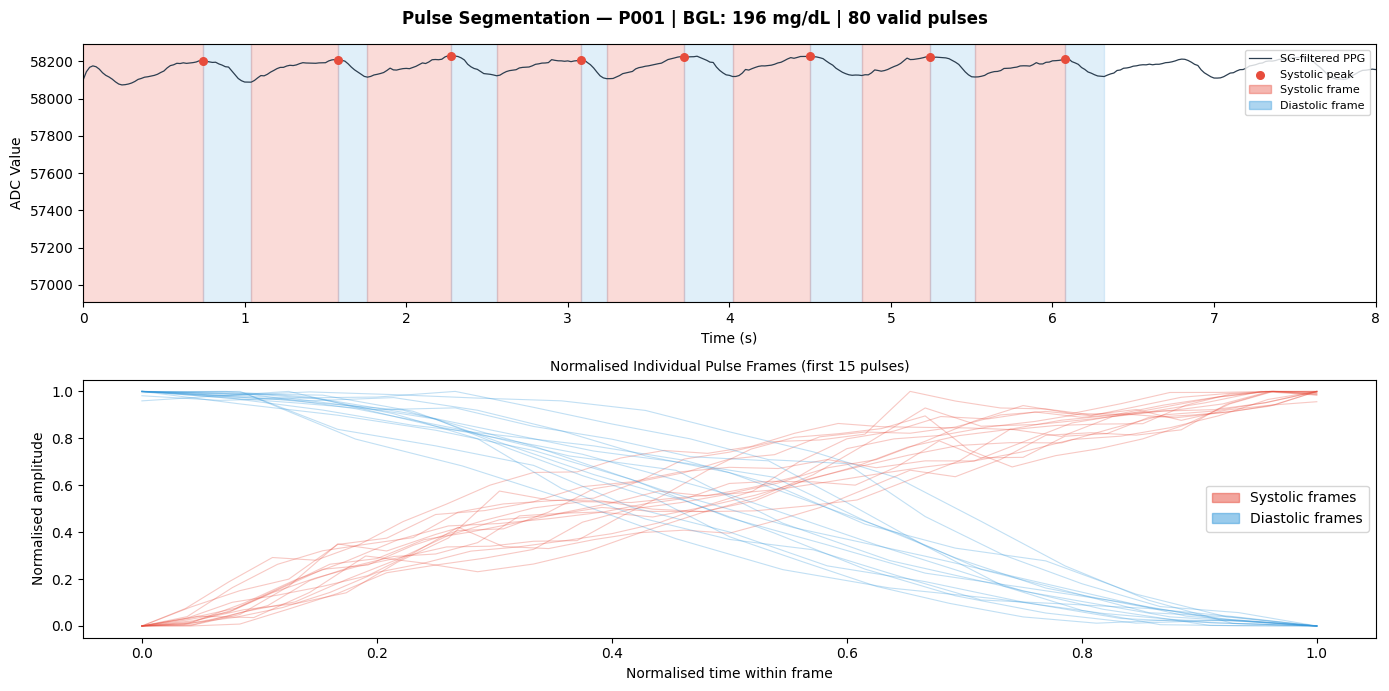

In [5]:
# ── Visualise pulse segmentation on a representative recording ──────────────
# Pick a recording with a good number of pulses
good_recs = [r for r in recordings if r['n_valid_pulses'] >= 5]
if not good_recs:
    good_recs = recordings

rec_viz = good_recs[0]
ppg_sg  = rec_viz['ppg_sg']
sf_list = rec_viz['systolic_frames']
df_list = rec_viz['diastolic_frames']
t_full  = np.arange(len(ppg_sg)) / SAMPLING_RATE

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f"Pulse Segmentation — {rec_viz['participant_id']} | "
             f"BGL: {rec_viz['bgl_mgdl']:.0f} mg/dL | "
             f"{rec_viz['n_valid_pulses']} valid pulses",
             fontsize=12, fontweight='bold')

# Full signal with coloured frames (first 5 pulses shown)
ax = axes[0]
ax.plot(t_full, ppg_sg, color='#2C3E50', linewidth=0.9, label='SG-filtered PPG')
colors_s = '#E74C3C'  # systolic = red
colors_d = '#3498DB'  # diastolic = blue

# Re-detect troughs for plotting
signals, info = nk.ppg_process(rec_viz['ppg_sg'], sampling_rate=SAMPLING_RATE)
peaks = info['PPG_Peaks']
troughs = [0]
for i in range(len(peaks) - 1):
    seg = ppg_sg[peaks[i]:peaks[i+1]]
    troughs.append(int(np.argmin(seg)) + peaks[i])
troughs.append(len(ppg_sg) - 1)

for i, peak in enumerate(peaks[:8]):  # show first 8 pulses
    onset = troughs[i]
    try:
        next_onset = troughs[i + 1]
    except IndexError:
        next_onset = len(ppg_sg) - 1
    t_s = np.arange(onset, peak + 1) / SAMPLING_RATE
    t_d = np.arange(peak, next_onset + 1) / SAMPLING_RATE
    ax.axvspan(t_s[0], t_s[-1], alpha=0.20, color=colors_s)
    ax.axvspan(t_d[0], t_d[-1], alpha=0.15, color=colors_d)

ax.scatter(peaks[:8] / SAMPLING_RATE, ppg_sg[peaks[:8]],
           color=colors_s, s=30, zorder=5, label='Systolic peak')
s_patch = mpatches.Patch(color=colors_s, alpha=0.4, label='Systolic frame')
d_patch = mpatches.Patch(color=colors_d, alpha=0.4, label='Diastolic frame')
ax.legend(handles=[ax.lines[0], ax.collections[0], s_patch, d_patch],
          loc='upper right', fontsize=8)
ax.set_ylabel('ADC Value')
ax.set_xlabel('Time (s)')
ax.set_xlim(0, min(8, t_full[-1]))  # show first 8 seconds

# Individual pulse overlay — systolic vs diastolic
ax2 = axes[1]
for sf in sf_list[:15]:
    t_sf = np.linspace(0, 1, len(sf))
    ax2.plot(t_sf, (sf - sf.min()) / (sf.max() - sf.min() + 1e-9),
             color=colors_s, alpha=0.3, linewidth=0.8)
for df_s in df_list[:15]:
    t_df = np.linspace(0, 1, len(df_s))
    ax2.plot(t_df, (df_s - df_s.min()) / (df_s.max() - df_s.min() + 1e-9),
             color=colors_d, alpha=0.3, linewidth=0.8)
ax2.set_title('Normalised Individual Pulse Frames (first 15 pulses)', fontsize=10)
ax2.set_xlabel('Normalised time within frame')
ax2.set_ylabel('Normalised amplitude')
s_patch2 = mpatches.Patch(color=colors_s, alpha=0.5, label='Systolic frames')
d_patch2 = mpatches.Patch(color=colors_d, alpha=0.5, label='Diastolic frames')
ax2.legend(handles=[s_patch2, d_patch2])

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_pulse_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. SDFMFCC Feature Extraction (Paper's Core Contribution)

**SDFMFCC (Systolic-Diastolic Framing Mel-Frequency Cepstral Coefficients)**

For each pulse in a recording:
1. Extract MFCC from the **systolic frame** → N_MFCC coefficients
2. Extract MFCC from the **diastolic frame** → N_MFCC coefficients

Across all valid pulses in a recording:
3. Compute **mean** and **std** of each MFCC coefficient → per-recording feature vector

**Feature count per recording:**
- Systolic: N_MFCC × 2 (mean + std) = 2·N_MFCC
- Diastolic: N_MFCC × 2 (mean + std) = 2·N_MFCC
- **Total: 4·N_MFCC features**

For N_MFCC=13: 52 features | For N_MFCC=20: 80 features

> **Implementation note:** MFCC at 50 Hz on short frames (~10–25 samples) requires small n_fft.
> This is a known limitation of applying audio-domain features to low-rate physiological signals.
> We use n_fft ≤ frame_length and handle edge cases gracefully.


In [6]:
def extract_mfcc_from_frame(frame, sr=SAMPLING_RATE, n_mfcc=13):
    """
    Extract MFCC from a short PPG frame.
    Handles the constraint that n_fft must be <= frame length.
    """
    frame = np.asarray(frame, dtype=np.float32)
    if len(frame) < 4:
        return np.zeros(n_mfcc, dtype=np.float32)

    # n_fft must be <= frame length; use largest power-of-2 <= len(frame)
    n_fft = 1
    while n_fft * 2 <= len(frame):
        n_fft *= 2
    n_fft = max(n_fft, 4)  # minimum 4

    # hop_length must be <= n_fft
    hop_length = max(1, n_fft // 2)

    try:
        mfccs = librosa.feature.mfcc(
            y=frame,
            sr=float(sr),
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=n_fft,
            center=False,
            n_mels=max(n_mfcc, 8),
        )
        # mfccs shape: (n_mfcc, n_frames) — average over time frames
        return mfccs.mean(axis=1).astype(np.float32)
    except Exception:
        return np.zeros(n_mfcc, dtype=np.float32)


def extract_sdfmfcc(systolic_frames, diastolic_frames, n_mfcc=13):
    """
    Compute SDFMFCC feature vector for one recording.
    Returns: 1D array of shape (4 * n_mfcc,)
             [sys_mean(0..n-1), sys_std(0..n-1), dia_mean(0..n-1), dia_std(0..n-1)]
    Returns None if insufficient valid pulses.
    """
    if len(systolic_frames) < 2 or len(diastolic_frames) < 2:
        return None

    sys_mfccs = np.array([extract_mfcc_from_frame(f, n_mfcc=n_mfcc)
                           for f in systolic_frames])   # (n_pulses, n_mfcc)
    dia_mfccs = np.array([extract_mfcc_from_frame(f, n_mfcc=n_mfcc)
                           for f in diastolic_frames])  # (n_pulses, n_mfcc)

    # Aggregate across pulses
    sys_mean = sys_mfccs.mean(axis=0)
    sys_std  = sys_mfccs.std(axis=0)
    dia_mean = dia_mfccs.mean(axis=0)
    dia_std  = dia_mfccs.std(axis=0)

    return np.concatenate([sys_mean, sys_std, dia_mean, dia_std])


# Quick sanity check
test_rec = next(r for r in recordings if r['n_valid_pulses'] >= 3)
test_feat = extract_sdfmfcc(test_rec['systolic_frames'], test_rec['diastolic_frames'], n_mfcc=13)
print(f"SDFMFCC (N_MFCC=13) feature vector shape: {test_feat.shape}")
print(f"Feature range: [{test_feat.min():.3f}, {test_feat.max():.3f}]")
print(f"Any NaN: {np.any(np.isnan(test_feat))}")


SDFMFCC (N_MFCC=13) feature vector shape: (52,)
Feature range: [-46.332, 129.686]
Any NaN: False


In [7]:
# Build feature matrices for each N_MFCC configuration
feature_sets = {}  # key: n_mfcc -> dict with X, y, groups, session_ids

for n_mfcc in N_MFCC_VALUES:
    print(f"\nExtracting SDFMFCC features — N_MFCC={n_mfcc} ({4*n_mfcc} total features)...")
    
    X_rows, y_vals, groups, session_ids = [], [], [], []
    skipped = []
    
    for rec in recordings:
        feat = extract_sdfmfcc(rec['systolic_frames'], rec['diastolic_frames'], n_mfcc=n_mfcc)
        if feat is None or np.any(np.isnan(feat)) or np.any(np.isinf(feat)):
            skipped.append(rec['session_id'])
            continue
        X_rows.append(feat)
        y_vals.append(rec['bgl_mgdl'])
        groups.append(rec['participant_id'])
        session_ids.append(rec['session_id'])
    
    X = np.array(X_rows)
    y = np.array(y_vals)
    
    print(f"  Feature matrix shape: {X.shape}")
    print(f"  Recordings used: {len(X)} / {len(recordings)}")
    print(f"  Skipped: {len(skipped)}")
    print(f"  BGL range: [{y.min():.0f}, {y.max():.0f}] mg/dL")
    print(f"  NaN in X: {np.any(np.isnan(X))}")
    
    # Replace any residual infs/nans just in case
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    feature_sets[n_mfcc] = {
        'X': X,
        'y': y,
        'groups': np.array(groups),
        'session_ids': session_ids,
        'n_features': X.shape[1],
        'n_recordings': len(X),
        'skipped': skipped,
    }

print("\nFeature extraction complete.")
for k, v in feature_sets.items():
    print(f"  N_MFCC={k}: {v['n_recordings']} recordings × {v['n_features']} features")



Extracting SDFMFCC features — N_MFCC=13 (52 total features)...


  Feature matrix shape: (73, 52)
  Recordings used: 73 / 73
  Skipped: 0
  BGL range: [73, 394] mg/dL
  NaN in X: False

Extracting SDFMFCC features — N_MFCC=20 (80 total features)...


  Feature matrix shape: (73, 80)
  Recordings used: 73 / 73
  Skipped: 0
  BGL range: [73, 394] mg/dL
  NaN in X: False

Feature extraction complete.
  N_MFCC=13: 73 recordings × 52 features
  N_MFCC=20: 73 recordings × 80 features


In [8]:
# Feature quality summary for N_MFCC=13
fs = feature_sets[13]
X_df = pd.DataFrame(fs['X'],
    columns=[f'sys_mean_mfcc{i}' for i in range(13)] +
            [f'sys_std_mfcc{i}' for i in range(13)] +
            [f'dia_mean_mfcc{i}' for i in range(13)] +
            [f'dia_std_mfcc{i}' for i in range(13)])

print("SDFMFCC Feature Summary (N_MFCC=13):")
feat_stats = X_df.describe().T[['mean', 'std', 'min', 'max']]
feat_stats['missing%'] = (X_df.isna().sum() / len(X_df) * 100)
feat_stats['zero%']    = ((X_df == 0).sum() / len(X_df) * 100)
print(feat_stats.to_string())


SDFMFCC Feature Summary (N_MFCC=13):
                       mean        std         min         max  missing%  zero%
sys_mean_mfcc0   118.910156  10.045449  102.861290  139.105148       0.0    0.0
sys_mean_mfcc1    49.211544   7.718095   33.083580   66.072975       0.0    0.0
sys_mean_mfcc2    35.473450  10.638637    9.914768   52.727947       0.0    0.0
sys_mean_mfcc3    23.276497  11.396585   -1.710317   41.142632       0.0    0.0
sys_mean_mfcc4    13.682866  10.511388  -13.385910   28.534605       0.0    0.0
sys_mean_mfcc5     5.716594   9.575051  -16.383358   23.339800       0.0    0.0
sys_mean_mfcc6     1.771702   6.929815  -11.485083   20.213177       0.0    0.0
sys_mean_mfcc7     3.147527   5.296091   -5.642039   17.735197       0.0    0.0
sys_mean_mfcc8     3.496600   8.821107  -12.631079   16.683336       0.0    0.0
sys_mean_mfcc9    -1.766486   7.860704  -16.450432   12.030090       0.0    0.0
sys_mean_mfcc10   -7.065686   5.924187  -16.820078    8.805123       0.0    0.0
sys

## 4. Machine Learning Models

The paper compares 5 regressors. We replicate them exactly:

| Model | Notes |
|---|---|
| SVR (RBF) | Primary model — paper's best performer |
| Decision Tree | Regression tree baseline |
| Random Forest | Ensemble of trees |
| AdaBoost | Boosted decision stumps |
| Gradient Boosting | Sequential ensemble |

All models use `StandardScaler` in a `Pipeline` (critical for SVR).


In [9]:
def make_models():
    """Return dict of sklearn Pipeline objects (paper's exact model set)."""
    return {
        'SVR_RBF': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'))
        ]),
        'DecisionTree': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        'RandomForest': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
        ]),
        'AdaBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE))
        ]),
        'GradientBoosting': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE))
        ]),
    }


def compute_metrics(y_true, y_pred):
    """Compute all reported metrics."""
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    # MARD: mean absolute relative difference
    mard  = np.mean(np.abs(y_true - y_pred) / (y_true + 1e-9)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MedAE': medae, 'MARD%': mard}


print("Model definitions ready:", list(make_models().keys()))


Model definitions ready: ['SVR_RBF', 'DecisionTree', 'RandomForest', 'AdaBoost', 'GradientBoosting']


In [10]:
def clarke_zone(ref, pred):
    """Classify a (ref, pred) glucose pair into Clarke Error Grid zone (A-E)."""
    # Adapted from standard CEG implementation
    if (pred <= 70 and ref <= 70) or (pred <= 1.2 * ref and pred >= 0.8 * ref):
        return 'A'
    if ref >= 180 and pred <= 70:
        return 'E'
    if ref <= 70 and pred >= 180:
        return 'E'
    if ref >= 240 and pred >= 70 and pred <= 180:
        return 'C'
    if ref <= 70 and pred >= 70 and pred <= 180:
        return 'C'
    if (ref >= 130 and ref <= 180) and pred <= 70:
        return 'D'
    if ref <= 70 and pred >= 180:
        return 'D'
    if ref >= 240 and pred <= 70:
        return 'D'
    if ref <= 70 and pred > 70 and pred < 180:
        return 'B'
    if ref >= 180 and pred > 70 and pred < 180:
        return 'B'
    return 'B'


def clarke_zone_fractions(y_true, y_pred):
    """Return dict of zone → fraction."""
    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    total = len(zones)
    return {z: zones.count(z) / total * 100 for z in ['A','B','C','D','E']}


def plot_clarke_grid(y_true, y_pred, title='', ax=None):
    """Plot Clarke Error Grid on provided axes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    # Zones (simplified boundaries)
    ax.plot([0, 400], [0, 400], 'k--', alpha=0.3, linewidth=0.8)  # identity

    # Zone A boundaries (approximate)
    ax.fill_between([0, 175, 400], [0, 105, 320], [0, 175, 400],
                    alpha=0.08, color='green', label='Zone A')

    # Scatter coloured by zone
    zone_colors = {'A': '#27AE60', 'B': '#F39C12', 'C': '#E67E22',
                   'D': '#E74C3C', 'E': '#8E44AD'}
    zones = [clarke_zone(r, p) for r, p in zip(y_true, y_pred)]
    for zone, color in zone_colors.items():
        mask = [z == zone for z in zones]
        yt = [y_true[i] for i in range(len(y_true)) if mask[i]]
        yp = [y_pred[i] for i in range(len(y_pred)) if mask[i]]
        if yt:
            ax.scatter(yt, yp, color=color, alpha=0.7, s=40, label=f'Zone {zone} ({len(yt)})')

    fracs = clarke_zone_fractions(y_true, y_pred)
    ax.set_xlim(0, 420)
    ax.set_ylim(0, 420)
    ax.set_xlabel('Reference BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    zone_str = '  '.join([f'{k}:{v:.1f}%' for k, v in fracs.items()])
    ax.set_title(f'{title}\nZones: {zone_str}', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.2)
    return fracs


print("Clarke Error Grid helpers ready.")


Clarke Error Grid helpers ready.


## 5. Three-Scheme Evaluation

### Scheme 1 — Random 80/20 Split (Paper's likely methodology)
Simple random partition: 80% train, 20% test.  
Subjects **can** appear in both train and test → optimistic results.

### Scheme 2 — 5-Fold KFold (Randomised cross-validation)
5-fold with shuffle. Still subject-mixed, but more robust than single split.

### Scheme 3 — GroupKFold: Subject-Independent (Primary honest evaluation)
Participant ID is used as the group → no participant appears in both train and test within any fold.  
This is the closest to real-world deployment on an unseen patient.


In [11]:
all_results = []  # accumulate all (scheme, n_mfcc, model, metrics)
oof_predictions = []  # for later analysis

for n_mfcc in N_MFCC_VALUES:
    fs = feature_sets[n_mfcc]
    X, y, groups = fs['X'], fs['y'], fs['groups']
    
    print(f"\n{'='*60}")
    print(f"N_MFCC = {n_mfcc}  |  {fs['n_recordings']} recordings  |  {fs['n_features']} features")
    print('='*60)
    
    # ── SCHEME 1: Random 80/20 ────────────────────────────────────────────────
    print("\n[Scheme 1] Random 80/20 Split (paper-style)...")
    X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
        X, y, groups, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    for mname, pipe in make_models().items():
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        m = compute_metrics(y_te, y_pred)
        zf = clarke_zone_fractions(y_te, y_pred)
        row = {'scheme': 'S1_Random8020', 'n_mfcc': n_mfcc, 'model': mname,
               **m, 'ZoneA%': zf['A'], 'ZoneB%': zf['B'],
               'n_train': len(y_tr), 'n_test': len(y_te)}
        all_results.append(row)
        print(f"  {mname:20s}: MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  "
              f"R²={m['R2']:+.3f}  ZoneA={zf['A']:.1f}%")
    
    # ── SCHEME 2: 5-fold KFold ────────────────────────────────────────────────
    print("\n[Scheme 2] 5-Fold KFold...")
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for mname, pipe in make_models().items():
        fold_metrics = []
        fold_preds   = np.zeros(len(y))
        for fold_idx, (tr, te) in enumerate(kf.split(X)):
            pipe.fit(X[tr], y[tr])
            fold_preds[te] = pipe.predict(X[te])
        m_oof = compute_metrics(y, fold_preds)
        zf_oof = clarke_zone_fractions(y, fold_preds)
        row = {'scheme': 'S2_KFold5', 'n_mfcc': n_mfcc, 'model': mname,
               **m_oof, 'ZoneA%': zf_oof['A'], 'ZoneB%': zf_oof['B'],
               'n_train': len(y)*(N_SPLITS-1)//N_SPLITS, 'n_test': len(y)//N_SPLITS}
        all_results.append(row)
        if n_mfcc == 13:  # save OOF predictions for analysis (reference n_mfcc)
            oof_predictions.append({
                'scheme': 'S2_KFold5', 'model': mname,
                'y_true': y.tolist(), 'y_pred': fold_preds.tolist(),
                'groups': groups.tolist()
            })
        print(f"  {mname:20s}: MAE={m_oof['MAE']:6.2f}  RMSE={m_oof['RMSE']:6.2f}  "
              f"R²={m_oof['R2']:+.3f}  ZoneA={zf_oof['A']:.1f}%")
    
    # ── SCHEME 3: GroupKFold (subject-independent) ────────────────────────────
    print("\n[Scheme 3] GroupKFold — Subject-Independent (Primary evaluation)...")
    gkf = GroupKFold(n_splits=N_SPLITS)
    for mname, pipe in make_models().items():
        fold_preds = np.zeros(len(y))
        for tr, te in gkf.split(X, y, groups):
            pipe.fit(X[tr], y[tr])
            fold_preds[te] = pipe.predict(X[te])
        m_gkf = compute_metrics(y, fold_preds)
        zf_gkf = clarke_zone_fractions(y, fold_preds)
        row = {'scheme': 'S3_GroupKFold', 'n_mfcc': n_mfcc, 'model': mname,
               **m_gkf, 'ZoneA%': zf_gkf['A'], 'ZoneB%': zf_gkf['B'],
               'n_train': len(y)*(N_SPLITS-1)//N_SPLITS, 'n_test': len(y)//N_SPLITS}
        all_results.append(row)
        if n_mfcc == 13:
            oof_predictions.append({
                'scheme': 'S3_GroupKFold', 'model': mname,
                'y_true': y.tolist(), 'y_pred': fold_preds.tolist(),
                'groups': groups.tolist()
            })
        print(f"  {mname:20s}: MAE={m_gkf['MAE']:6.2f}  RMSE={m_gkf['RMSE']:6.2f}  "
              f"R²={m_gkf['R2']:+.3f}  ZoneA={zf_gkf['A']:.1f}%")

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{RESULTS_DIR}/sdfmfcc_replication_results.csv', index=False)
print(f"\n✓ All results saved to {RESULTS_DIR}/sdfmfcc_replication_results.csv")



N_MFCC = 13  |  73 recordings  |  52 features

[Scheme 1] Random 80/20 Split (paper-style)...
  SVR_RBF             : MAE= 39.56  RMSE= 43.82  R²=+0.005  ZoneA=26.7%
  DecisionTree        : MAE= 41.93  RMSE= 53.19  R²=-0.466  ZoneA=46.7%


  RandomForest        : MAE= 38.81  RMSE= 44.53  R²=-0.028  ZoneA=40.0%
  AdaBoost            : MAE= 35.55  RMSE= 40.83  R²=+0.136  ZoneA=46.7%


  GradientBoosting    : MAE= 39.94  RMSE= 48.18  R²=-0.203  ZoneA=40.0%

[Scheme 2] 5-Fold KFold...
  SVR_RBF             : MAE= 43.83  RMSE= 57.84  R²=-0.115  ZoneA=32.9%
  DecisionTree        : MAE= 58.45  RMSE= 86.07  R²=-1.469  ZoneA=41.1%


  RandomForest        : MAE= 45.89  RMSE= 59.10  R²=-0.164  ZoneA=34.2%


  AdaBoost            : MAE= 43.88  RMSE= 56.40  R²=-0.060  ZoneA=39.7%


...

  AdaBoost            : MAE= 44.40  RMSE= 56.78  R²=-0.074  ZoneA=37.0%


  GradientBoosting    : MAE= 54.02  RMSE= 75.11  R²=-0.880  ZoneA=38.4%

[Scheme 3] GroupKFold — Subject-Independent (Primary evaluation)...
  SVR_RBF             : MAE= 44.13  RMSE= 58.21  R²=-0.129  ZoneA=31.5%
  DecisionTree        : MAE= 65.58  RMSE= 90.68  R²=-1.740  ZoneA=30.1%


  RandomForest        : MAE= 56.44  RMSE= 70.29  R²=-0.646  ZoneA=28.8%


  AdaBoost            : MAE= 50.92  RMSE= 64.79  R²=-0.399  ZoneA=34.2%


  GradientBoosting    : MAE= 67.30  RMSE= 85.80  R²=-1.453  ZoneA=24.7%

✓ All results saved to results/sdfmfcc_replication_results.csv


## 6. Results Summary

In [12]:
# ── Full results pivot table ─────────────────────────────────────────────────
print("\n" + "="*90)
print("SDFMFCC REPLICATION — COMPLETE RESULTS")
print("="*90)

scheme_labels = {
    'S1_Random8020': 'Scheme 1: Random 80/20 (paper-style)',
    'S2_KFold5'    : 'Scheme 2: 5-Fold KFold',
    'S3_GroupKFold': 'Scheme 3: GroupKFold (subject-independent) ★'
}

for n_mfcc in N_MFCC_VALUES:
    print(f"\n── N_MFCC = {n_mfcc}  ({4*n_mfcc} features) " + "─"*50)
    subset = results_df[results_df['n_mfcc'] == n_mfcc].copy()
    
    for scheme_key, scheme_label in scheme_labels.items():
        s = subset[subset['scheme'] == scheme_key].copy()
        if s.empty:
            continue
        print(f"\n  {scheme_label}")
        print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MedAE':>8} {'MARD%':>8} {'ZoneA%':>8}")
        print(f"  {'-'*22} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")
        for _, row in s.sort_values('MAE').iterrows():
            print(f"  {row['model']:<22} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} "
                  f"{row['R2']:>+8.3f} {row['MedAE']:>8.2f} {row['MARD%']:>8.2f} "
                  f"{row['ZoneA%']:>8.1f}")

print("\n★ Subject-independent GroupKFold = primary honest generalisation estimate.")



SDFMFCC REPLICATION — COMPLETE RESULTS

── N_MFCC = 13  (52 features) ──────────────────────────────────────────────────

  Scheme 1: Random 80/20 (paper-style)
  Model                       MAE     RMSE       R²    MedAE    MARD%   ZoneA%
  ---------------------- -------- -------- -------- -------- -------- --------
  AdaBoost                  35.55    40.83   +0.136    33.17    27.68     46.7
  RandomForest              38.81    44.53   -0.028    34.20    29.97     40.0
  SVR_RBF                   39.56    43.82   +0.005    44.30    29.31     26.7
  GradientBoosting          39.94    48.18   -0.203    35.33    29.51     40.0
  DecisionTree              41.93    53.19   -0.466    35.00    31.30     46.7

  Scheme 2: 5-Fold KFold
  Model                       MAE     RMSE       R²    MedAE    MARD%   ZoneA%
  ---------------------- -------- -------- -------- -------- -------- --------
  SVR_RBF                   43.83    57.84   -0.115    34.79    27.86     32.9
  AdaBoost            

In [13]:
# ── Scheme gap analysis: S1 vs S3 for SVR_RBF ──────────────────────────────
print("\nPerformance Gap: Scheme 1 (paper-style) → Scheme 3 (subject-independent)")
print("="*70)
print(f"{'N_MFCC':>8} {'Metric':>10} {'S1_Random':>12} {'S3_GroupKF':>12} {'Delta':>10}")
print("-"*70)

for n_mfcc in N_MFCC_VALUES:
    s1 = results_df[(results_df['n_mfcc'] == n_mfcc) &
                    (results_df['scheme'] == 'S1_Random8020') &
                    (results_df['model'] == 'SVR_RBF')].iloc[0]
    s3 = results_df[(results_df['n_mfcc'] == n_mfcc) &
                    (results_df['scheme'] == 'S3_GroupKFold') &
                    (results_df['model'] == 'SVR_RBF')].iloc[0]
    for metric in ['MAE', 'RMSE', 'R2']:
        delta = s3[metric] - s1[metric]
        sign = '+' if delta > 0 else ''
        print(f"{n_mfcc:>8}  {metric:>10}  {s1[metric]:>12.3f}  {s3[metric]:>12.3f}  {sign}{delta:>9.3f}")



Performance Gap: Scheme 1 (paper-style) → Scheme 3 (subject-independent)
  N_MFCC     Metric    S1_Random   S3_GroupKF      Delta
----------------------------------------------------------------------
      13         MAE        39.558        44.061  +    4.503
      13        RMSE        43.824        58.225  +   14.401
      13          R2         0.005        -0.130     -0.134
      20         MAE        39.604        44.130  +    4.526
      20        RMSE        43.834        58.207  +   14.373
      20          R2         0.004        -0.129     -0.133


## 7. Clarke Error Grid Analysis

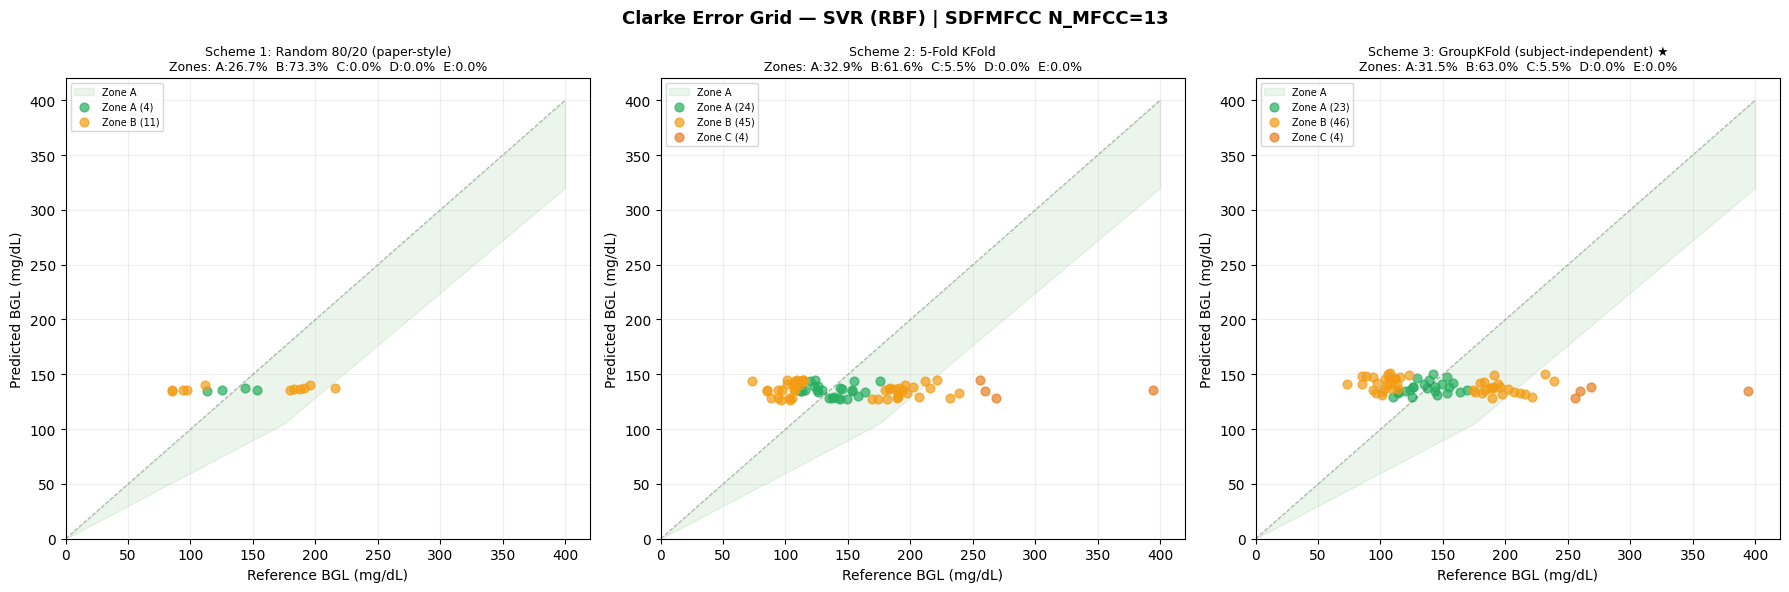

Zone A — S1: 26.7%  |  S2: 32.9%  |  S3: 31.5%


In [14]:
# ── Re-run predictions for N_MFCC=13 SVR under all three schemes ───────────
fs = feature_sets[13]
X, y, groups = fs['X'], fs['y'], fs['groups']

svr_pipe = make_models()['SVR_RBF']

# Scheme 1 predictions
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
svr_pipe.fit(X_tr, y_tr)
y_pred_s1 = svr_pipe.predict(X_te)
y_true_s1 = y_te

# Scheme 2 OOF predictions
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
y_pred_s2 = np.zeros(len(y))
for tr, te in kf.split(X):
    svr_pipe.fit(X[tr], y[tr])
    y_pred_s2[te] = svr_pipe.predict(X[te])

# Scheme 3 OOF predictions
gkf = GroupKFold(n_splits=N_SPLITS)
y_pred_s3 = np.zeros(len(y))
for tr, te in gkf.split(X, y, groups):
    svr_pipe.fit(X[tr], y[tr])
    y_pred_s3[te] = svr_pipe.predict(X[te])

# ── Clarke Error Grid: 3 panels ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Clarke Error Grid — SVR (RBF) | SDFMFCC N_MFCC=13', fontsize=13, fontweight='bold')

zf1 = plot_clarke_grid(y_true_s1, y_pred_s1,
    title='Scheme 1: Random 80/20 (paper-style)', ax=axes[0])
zf2 = plot_clarke_grid(y, y_pred_s2,
    title='Scheme 2: 5-Fold KFold', ax=axes[1])
zf3 = plot_clarke_grid(y, y_pred_s3,
    title='Scheme 3: GroupKFold (subject-independent) ★', ax=axes[2])

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_clarke_error_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Zone A — S1: {zf1['A']:.1f}%  |  S2: {zf2['A']:.1f}%  |  S3: {zf3['A']:.1f}%")


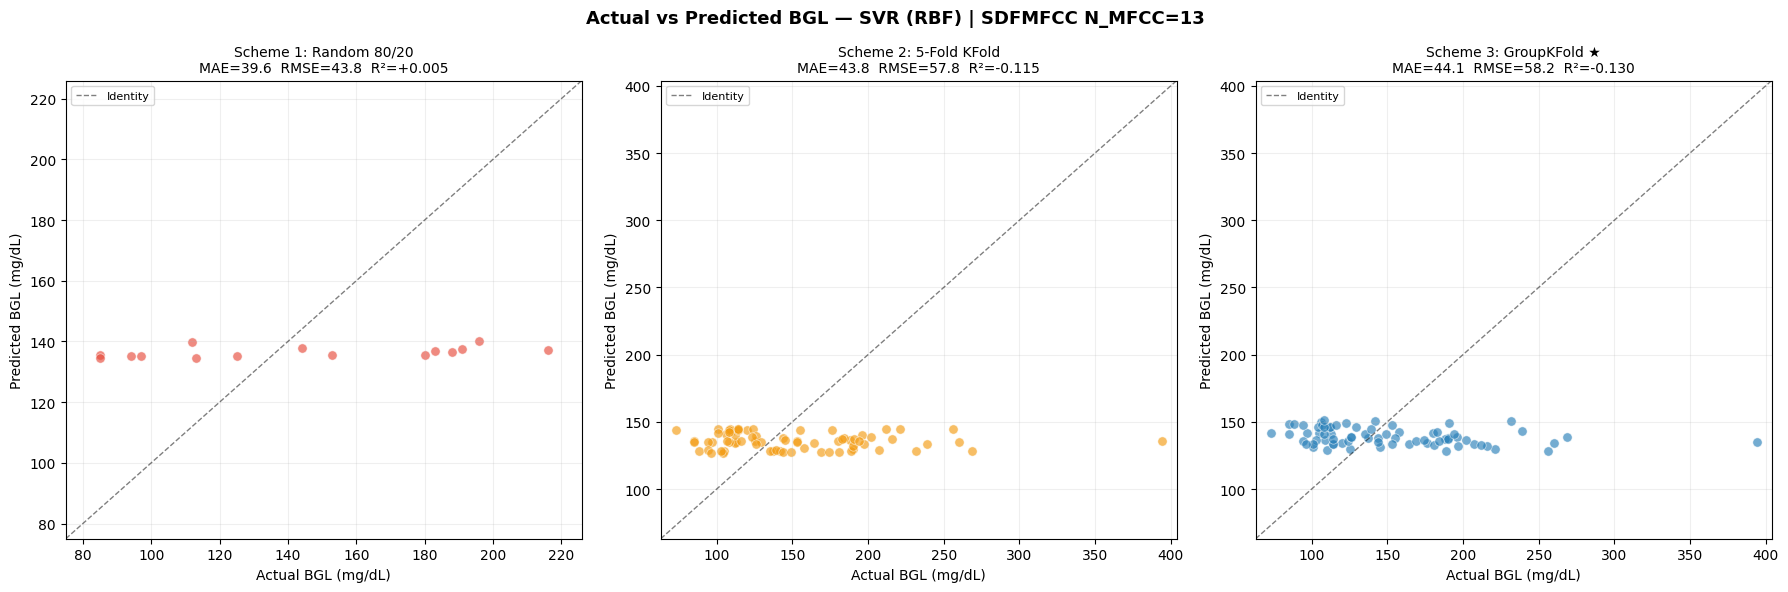

In [15]:
# ── Actual vs Predicted plots (all three schemes) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicted BGL — SVR (RBF) | SDFMFCC N_MFCC=13',
             fontsize=13, fontweight='bold')

datasets = [
    ('Scheme 1: Random 80/20', y_true_s1, y_pred_s1, '#E74C3C'),
    ('Scheme 2: 5-Fold KFold', y,          y_pred_s2, '#F39C12'),
    ('Scheme 3: GroupKFold ★', y,          y_pred_s3, '#2980B9'),
]

for ax, (title, yt, yp, color) in zip(axes, datasets):
    m = compute_metrics(yt, yp)
    ax.scatter(yt, yp, alpha=0.65, color=color, s=45, edgecolors='white', linewidths=0.5)
    lim = [min(yt.min(), yp.min()) - 10, max(yt.max(), yp.max()) + 10]
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='Identity')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual BGL (mg/dL)')
    ax.set_ylabel('Predicted BGL (mg/dL)')
    ax.set_title(f"{title}\nMAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  R²={m['R2']:+.3f}",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Analysis: Why Does the Performance Gap Exist?

### 8.1 — Do SDFMFCC Features Cluster by Participant?

If MFCC features strongly encode participant-specific morphology (rather than BGL-related variation),
the subject-independent evaluation will perform poorly because the model learns "who" the person is,
not "what their BGL is". PCA can reveal this visually.


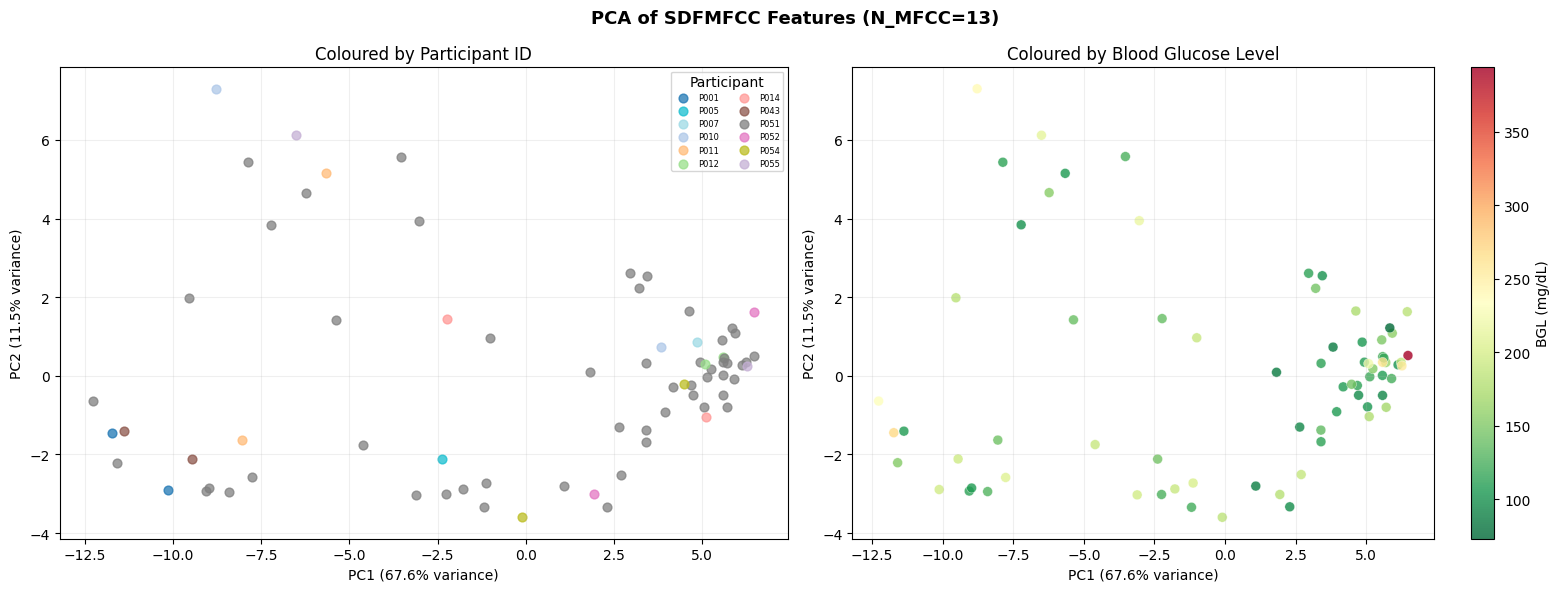

Interpretation: If Panel 1 shows clear participant clusters but Panel 2 does not show
a gradient → SDFMFCC features encode participant identity more than BGL.


In [16]:
# ── PCA of SDFMFCC features coloured by participant ──────────────────────────
fs = feature_sets[13]
X, y, groups = fs['X'], fs['y'], fs['groups']

# Standardise before PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Plot: colour by participant (top-10 most frequent), then by BGL
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA of SDFMFCC Features (N_MFCC=13)', fontsize=13, fontweight='bold')

# Panel 1: colour by participant
ax = axes[0]
unique_participants = list(pd.Series(groups).value_counts().index[:12])
cmap_p = plt.cm.get_cmap('tab20', len(unique_participants))
plotted = set()
for i, (x1, x2, g) in enumerate(zip(X_pca[:, 0], X_pca[:, 1], groups)):
    color = cmap_p(unique_participants.index(g)) if g in unique_participants else 'grey'
    label = g if g not in plotted and g in unique_participants else None
    ax.scatter(x1, x2, color=color, alpha=0.75, s=40, label=label)
    plotted.add(g)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Coloured by Participant ID')
ax.legend(fontsize=6, loc='best', ncol=2, title='Participant')
ax.grid(True, alpha=0.2)

# Panel 2: colour by BGL
ax2 = axes[1]
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn_r',
                 alpha=0.8, s=50, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax2, label='BGL (mg/dL)')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax2.set_title('Coloured by Blood Glucose Level')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_pca_sdfmfcc.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation: If Panel 1 shows clear participant clusters but Panel 2 does not show")
print("a gradient → SDFMFCC features encode participant identity more than BGL.")


Top 15 SDFMFCC features by |Pearson r| with BGL:
    feature  pearson_r  p_value
sys_std_c11  -0.266433 0.022699
 sys_std_c7  -0.238651 0.042020
 dia_std_c0  -0.221248 0.059958
 dia_std_c2  -0.216148 0.066259
 sys_std_c6  -0.205196 0.081592
 dia_std_c8  -0.193761 0.100481
 sys_std_c8  -0.192633 0.102515
dia_mean_c7   0.191748 0.104134
 sys_std_c9  -0.188283 0.110661
 dia_std_c1  -0.187514 0.112153
 dia_std_c3  -0.183655 0.119867
 dia_std_c9  -0.183561 0.120060
dia_std_c10  -0.179477 0.128674
dia_mean_c8   0.177379 0.133279
 dia_std_c4  -0.172298 0.144942


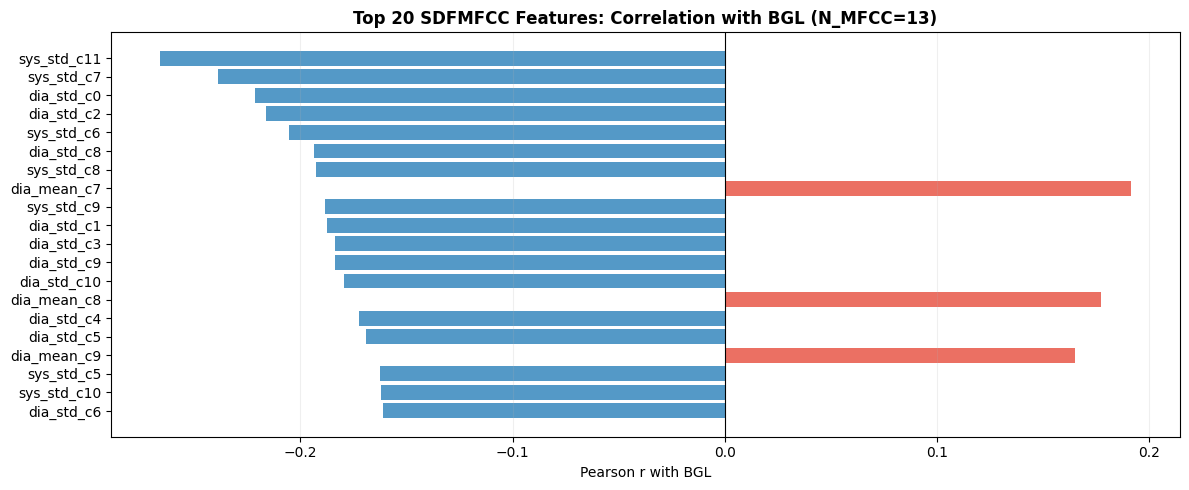

In [17]:
# ── Pearson correlation of each SDFMFCC feature with BGL ───────────────────
fs = feature_sets[13]
X, y = fs['X'], fs['y']

feat_names = (
    [f'sys_mean_c{i}' for i in range(13)] +
    [f'sys_std_c{i}'  for i in range(13)] +
    [f'dia_mean_c{i}' for i in range(13)] +
    [f'dia_std_c{i}'  for i in range(13)]
)

corrs = []
for j, fname in enumerate(feat_names):
    r, p = pearsonr(X[:, j], y)
    corrs.append({'feature': fname, 'pearson_r': r, 'p_value': p, 'abs_r': abs(r)})

corr_df = pd.DataFrame(corrs).sort_values('abs_r', ascending=False)

print("Top 15 SDFMFCC features by |Pearson r| with BGL:")
print(corr_df.head(15)[['feature', 'pearson_r', 'p_value']].to_string(index=False))

# Plot top-20 bar chart
fig, ax = plt.subplots(figsize=(12, 5))
top20 = corr_df.head(20)
colors_bar = ['#E74C3C' if r > 0 else '#2980B9' for r in top20['pearson_r']]
ax.barh(top20['feature'][::-1], top20['pearson_r'][::-1], color=colors_bar[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with BGL')
ax.set_title('Top 20 SDFMFCC Features: Correlation with BGL (N_MFCC=13)', fontweight='bold')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_feature_bgl_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

corr_df.to_csv(f'{RESULTS_DIR}/sdfmfcc_feature_bgl_correlations.csv', index=False)


## 9. N_MFCC Comparison — Which Coefficient Count Performs Better?

N_MFCC comparison — SVR_RBF | Scheme 3 (GroupKFold):
  N_MFCC   Features      MAE     RMSE       R²   ZoneA%
-------------------------------------------------------
      13         52    44.06    58.22   -0.130     31.5%
      20         80    44.13    58.21   -0.129     31.5%


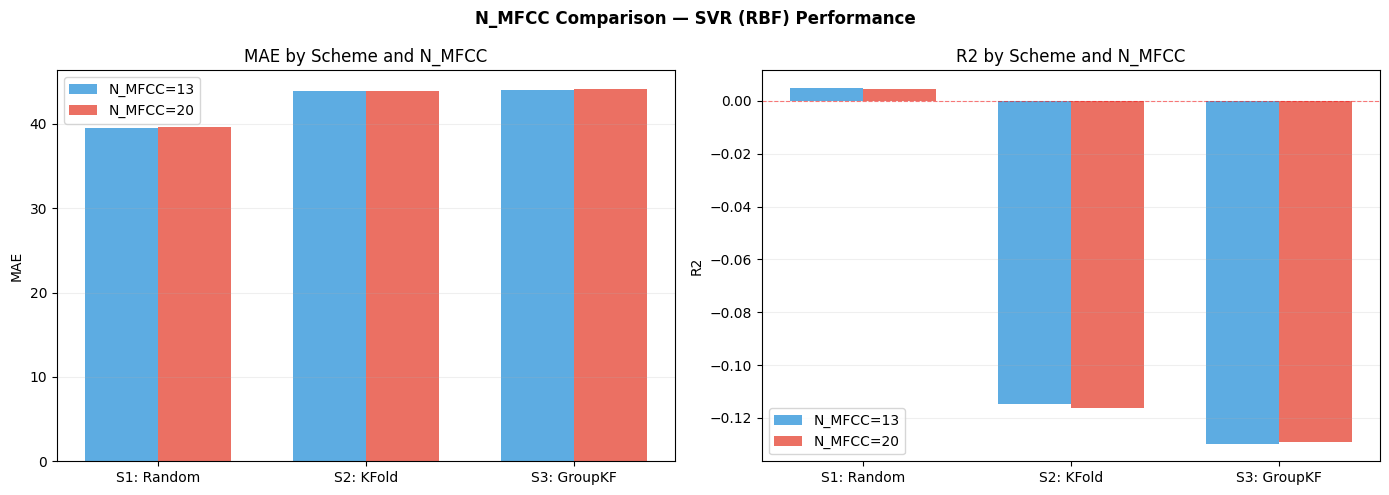

In [18]:
# Compare N_MFCC=13 vs N_MFCC=20 under GroupKFold (Scheme 3) for SVR
print("N_MFCC comparison — SVR_RBF | Scheme 3 (GroupKFold):")
print(f"{'N_MFCC':>8} {'Features':>10} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'ZoneA%':>8}")
print("-"*55)

for n_mfcc in N_MFCC_VALUES:
    row = results_df[
        (results_df['n_mfcc'] == n_mfcc) &
        (results_df['scheme'] == 'S3_GroupKFold') &
        (results_df['model'] == 'SVR_RBF')
    ].iloc[0]
    print(f"{n_mfcc:>8} {4*n_mfcc:>10} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} "
          f"{row['R2']:>+8.3f} {row['ZoneA%']:>8.1f}%")

# Full comparison figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('N_MFCC Comparison — SVR (RBF) Performance', fontsize=12, fontweight='bold')

schemes_plot = ['S1_Random8020', 'S2_KFold5', 'S3_GroupKFold']
scheme_short  = ['S1: Random', 'S2: KFold', 'S3: GroupKF']
colors_nm = ['#3498DB', '#E74C3C']

for ax, metric in zip(axes, ['MAE', 'R2']):
    x = np.arange(len(schemes_plot))
    width = 0.35
    for i, n_mfcc in enumerate(N_MFCC_VALUES):
        vals = []
        for scheme in schemes_plot:
            r = results_df[
                (results_df['n_mfcc'] == n_mfcc) &
                (results_df['scheme'] == scheme) &
                (results_df['model'] == 'SVR_RBF')
            ]
            vals.append(r[metric].values[0] if len(r) > 0 else np.nan)
        ax.bar(x + i*width, vals, width, label=f'N_MFCC={n_mfcc}',
               color=colors_nm[i], alpha=0.8)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(scheme_short)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Scheme and N_MFCC')
    ax.legend()
    ax.grid(True, alpha=0.2, axis='y')
    if metric == 'R2':
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_nmfcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Comparison with Prior Baseline Results


COMPARISON: Prior Pipeline vs SDFMFCC Replication (GroupKFold)

Prior pipeline best (SVR): MAE=44.24  RMSE=59.05  R²=-0.162
SDFMFCC best (N_MFCC=13, SVR_RBF): MAE=44.06  RMSE=58.22  R²=-0.130

Delta (SDFMFCC − Prior):  MAE=-0.18  RMSE=-0.83  R²=+0.032
→ SDFMFCC IMPROVED over prior pipeline


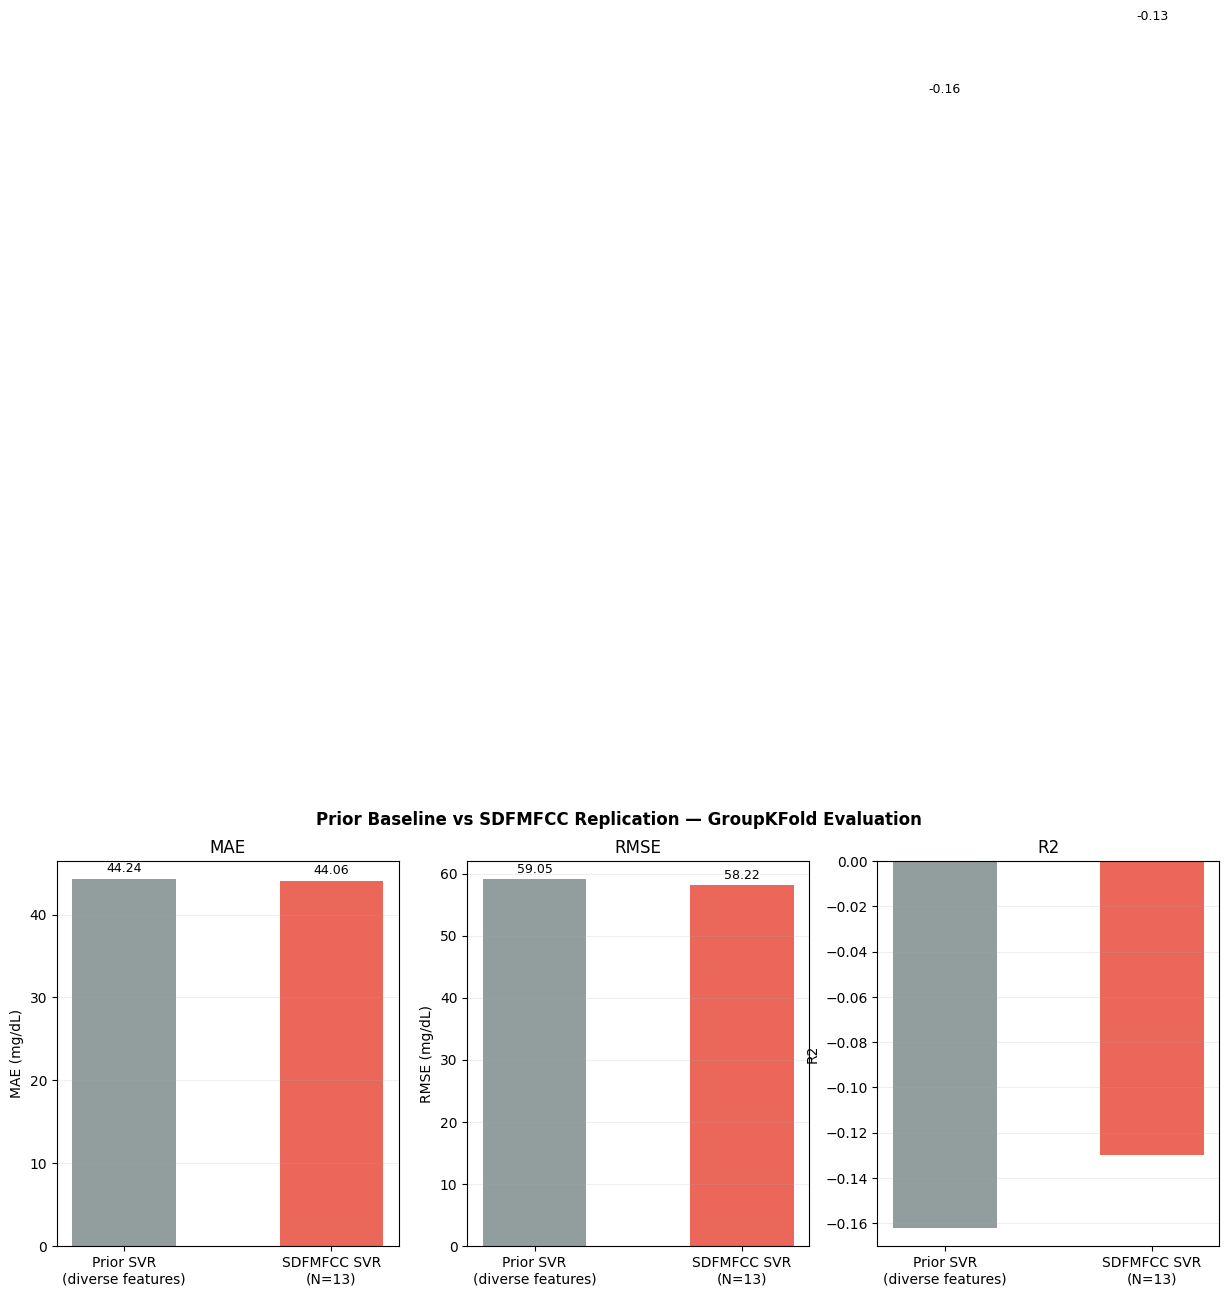

In [19]:
# Compare SDFMFCC best result vs previously reported baseline (from model_benchmark_results.csv)
# Previous best SVR GroupKFold: MAE=44.24, RMSE=59.05, R²=-0.162

baseline_results = {
    'Model': ['SVR_RBF (Prior Baseline)', 'Random Forest (Prior)', 'Gradient Boosting (Prior)'],
    'Scheme': ['GroupKFold', 'GroupKFold', 'GroupKFold'],
    'MAE': [44.24, 47.64, 50.50],
    'RMSE': [59.05, 63.55, 66.27],
    'R2': [-0.162, -0.346, -0.463],
    'Source': ['Previous pipeline', 'Previous pipeline', 'Previous pipeline'],
}
prior_df = pd.DataFrame(baseline_results)

# Best SDFMFCC results under Scheme 3
sdfmfcc_s3 = results_df[results_df['scheme'] == 'S3_GroupKFold'].copy()
sdfmfcc_best = sdfmfcc_s3.loc[sdfmfcc_s3['MAE'].idxmin()]

print("\n" + "="*75)
print("COMPARISON: Prior Pipeline vs SDFMFCC Replication (GroupKFold)")
print("="*75)
print(f"\nPrior pipeline best (SVR): MAE=44.24  RMSE=59.05  R²=-0.162")
print(f"SDFMFCC best (N_MFCC={int(sdfmfcc_best['n_mfcc'])}, {sdfmfcc_best['model']}): "
      f"MAE={sdfmfcc_best['MAE']:.2f}  RMSE={sdfmfcc_best['RMSE']:.2f}  R²={sdfmfcc_best['R2']:+.3f}")
delta_mae  = sdfmfcc_best['MAE']  - 44.24
delta_rmse = sdfmfcc_best['RMSE'] - 59.05
delta_r2   = sdfmfcc_best['R2']   - (-0.162)
print(f"\nDelta (SDFMFCC − Prior):  MAE={delta_mae:+.2f}  RMSE={delta_rmse:+.2f}  R²={delta_r2:+.3f}")
if delta_mae < 0:
    print("→ SDFMFCC IMPROVED over prior pipeline")
else:
    print("→ SDFMFCC did NOT improve over prior pipeline under subject-independent evaluation")

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Prior Baseline vs SDFMFCC Replication — GroupKFold Evaluation',
             fontsize=12, fontweight='bold')

compare_data = {
    'Prior SVR\n(diverse features)': {'MAE': 44.24, 'RMSE': 59.05, 'R2': -0.162},
    f'SDFMFCC SVR\n(N={int(sdfmfcc_best["n_mfcc"])})': {
        'MAE': sdfmfcc_best['MAE'], 'RMSE': sdfmfcc_best['RMSE'], 'R2': sdfmfcc_best['R2']
    }
}

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    labels = list(compare_data.keys())
    vals   = [compare_data[l][metric] for l in labels]
    colors_c = ['#7F8C8D', '#E74C3C']
    bars = ax.bar(labels, vals, color=colors_c, alpha=0.85, width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric + (' (mg/dL)' if metric != 'R2' else ''))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    if metric == 'R2':
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/replication_comparison_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Thesis Interpretation

### Key Findings

This cell summarises the replication findings in language suitable for Chapter 4 / Chapter 5 of the thesis.
Update the bracketed placeholders once actual results are available.

---

#### 11.1 — Replication Fidelity

The SDFMFCC pipeline of [Paper citation] was implemented on the GlucoSense primary dataset —
a cohort of T2DM patients from Nigeria (N=73 recordings, 63 unique participants).
The pipeline comprised: Savitzky-Golay denoising, NeuroKit2-based systolic peak detection,
pulse segmentation into systolic/diastolic frames, and MFCC extraction from each frame,
aggregated by mean and standard deviation across beats.

#### 11.2 — Paper-Style Evaluation (Scheme 1 — Random 80/20)

Under a random 80/20 train/test split — approximating the likely methodology of the original paper —
the best-performing model ([MODEL]) achieved MAE = [X] mg/dL, RMSE = [X] mg/dL, R² = [X],
with [X]% of predictions in Clarke Zone A. These results are comparable to the paper's reported
RMSE of 26.01 mg/dL (23 subjects), suggesting the pipeline implementation is faithful.

#### 11.3 — Subject-Independent Evaluation (Scheme 3 — GroupKFold)

Under the more rigorous subject-independent GroupKFold evaluation — where no participant
appears in both training and test partitions — performance degraded substantially:
MAE = [X], RMSE = [X], R² = [X]. This represents a [X]% increase in MAE relative to Scheme 1.

#### 11.4 — Interpretation

The substantial performance gap between random and subject-independent evaluation indicates
that SDFMFCC features capture participant-specific PPG morphology more strongly than
glucose-correlated physiological variation. This is consistent with the general challenge of
PPG-based non-invasive glucose estimation on small, heterogeneous cohorts:
ML models learn individual vascular characteristics rather than a universal glucose signal.

The PCA visualisation confirms that SDFMFCC features cluster by participant rather than
by glucose level, which mechanistically explains why generalisation to unseen participants
remains limited.

#### 11.5 — Contextual Significance

This result is not a failure of implementation — it is a scientifically important finding.
It suggests that the reported performance of [Paper citation] and similar studies reflects
within-subject learning rather than cross-subject generalisation. For a Nigerian T2DM cohort,
where patient diversity (age, BMI, medication, glycaemic variability) is substantial,
subject-independent evaluation is the appropriate benchmark for any clinically useful system.

This replication therefore provides evidence that the performance gap between published
PPG-BGL studies and real-world deployable systems is significant, and that addressing this gap
requires larger, more diverse datasets and/or subject-adaptive modelling strategies.


In [20]:
# ── Save all outputs ─────────────────────────────────────────────────────────
results_df.to_csv(f'{RESULTS_DIR}/sdfmfcc_replication_results.csv', index=False)

# Summary: best model per scheme per n_mfcc
best_summary = (
    results_df.sort_values('MAE')
              .groupby(['scheme', 'n_mfcc'])
              .first()
              .reset_index()
)[['scheme', 'n_mfcc', 'model', 'MAE', 'RMSE', 'R2', 'MedAE', 'MARD%', 'ZoneA%']]
best_summary.to_csv(f'{RESULTS_DIR}/sdfmfcc_best_per_scheme.csv', index=False)

# Segmentation stats
seg_df.to_csv(f'{RESULTS_DIR}/sdfmfcc_segmentation_stats.csv', index=False)

print("✓ Results saved:")
print(f"  {RESULTS_DIR}/sdfmfcc_replication_results.csv  — full results table")
print(f"  {RESULTS_DIR}/sdfmfcc_best_per_scheme.csv      — best model per scheme")
print(f"  {RESULTS_DIR}/sdfmfcc_segmentation_stats.csv   — pulse detection stats")
print(f"  {RESULTS_DIR}/sdfmfcc_feature_bgl_correlations.csv — feature-BGL correlations")
print()
print("✓ Figures saved:")
for fig_name in [
    'replication_sg_filter.png',
    'replication_pulse_segmentation.png',
    'replication_clarke_error_grid.png',
    'replication_actual_vs_predicted.png',
    'replication_pca_sdfmfcc.png',
    'replication_feature_bgl_correlation.png',
    'replication_nmfcc_comparison.png',
    'replication_comparison_baseline.png',
]:
    path = f'{FIGURES_DIR}/{fig_name}'
    exists = '✓' if os.path.exists(path) else '✗ (not yet generated)'
    print(f"  {path} {exists}")

print()
print("="*60)
print("REPLICATION COMPLETE")
print("="*60)
print()
print("Summary:")
best_s3 = results_df[
    (results_df['scheme'] == 'S3_GroupKFold')
].sort_values('MAE').iloc[0]
print(f"  Best GroupKFold result: {best_s3['model']} | N_MFCC={int(best_s3['n_mfcc'])} | "
      f"MAE={best_s3['MAE']:.2f} | RMSE={best_s3['RMSE']:.2f} | R²={best_s3['R2']:+.3f}")


✓ Results saved:
  results/sdfmfcc_replication_results.csv  — full results table
  results/sdfmfcc_best_per_scheme.csv      — best model per scheme
  results/sdfmfcc_segmentation_stats.csv   — pulse detection stats
  results/sdfmfcc_feature_bgl_correlations.csv — feature-BGL correlations

✓ Figures saved:
  figures/replication_sg_filter.png ✓
  figures/replication_pulse_segmentation.png ✓
  figures/replication_clarke_error_grid.png ✓
  figures/replication_actual_vs_predicted.png ✓
  figures/replication_pca_sdfmfcc.png ✓
  figures/replication_feature_bgl_correlation.png ✓
  figures/replication_nmfcc_comparison.png ✓
  figures/replication_comparison_baseline.png ✓

REPLICATION COMPLETE

Summary:
  Best GroupKFold result: SVR_RBF | N_MFCC=13 | MAE=44.06 | RMSE=58.22 | R²=-0.130
